# High-resolution multiparameter iFWI — full Marmousi2 (variable density)

Joint velocity–impedance $(v_p, Z)$ implicit FWI on the full Marmousi2 model, reproducing
the synthetic example of *Accelerating High-Resolution Implicit Full-Waveform Inversion*
(GJI FWIM). A single hash + SIREN network represents both $v_p$ and $Z$; the variable-density
`AcousticVRZ` sweep solver (compiled `impl='c'`, boundary-saving) models the data, and the
inversion runs a band-limited multiscale schedule with a **per-scale network + Adam restart**.

Parameters follow the paper (Table 1 / Synthetic section): 2×128 SIREN, hash levels 16 / features 1 /
base 16 / **finest 512** / log2 18; lowpass scales **3, 5, 8, all Hz**, 100 epochs each (400 total);
Adam `lr 1e-4`, `decay 0.999`, batch 16; free surface on top.

## Setup: models, acquisition, `AcousticVRZ` solver and observed data

In [1]:
import os

In [2]:
# ---------------- Marmousi2 (v_p + impedance) — paper parameters (GJI FWIM Table 1) ----------------
DH, DT      = 18.75, 0.002
SPATIAL_ORDER, ABCN = 8, 50              # 8th-order space, CPML(50)
NT, FM, DELAY = 4000, 12.0, 0.5          # 8.0 s record, Ricker fm = 12 Hz
SRC_INTERVAL, REC_INTERVAL = 4, 2        # sources every 75 m, receivers every 37.5 m (surface)
BATCH = 16
OMEGA, HIDDEN, LAYERS = 10.0, 128, 2     # SIREN: omega = 10, 2 hidden layers of 128
STD  = [4000.0, 10000.0]                 # per-parameter std: [v_p, z]  (model = init + std * net)
MEAN = [0.0, 0.0]
HASH_CFG = dict(n_levels=16, n_features_per_level=1, log2_hashmap_size=18,
                base_resolution=16, finest_resolution=512)   # paper Table 1 (finest 512)
FREQS = [3.0, 5.0, 8.0, None]            # lowpass multiscale 3 / 5 / 8 / all Hz; None = unfiltered
NN_LR, LR_DECAY = 1e-4, 0.999            # Adam lr = 1e-4, per-step decay 0.999, restart per scale
TAG = "marmousi2_mp"

SMOKE = False                            # True = quick check; False = full run (use a GPU)
EPOCHS_PER_SCALE = int(os.environ.get("IFWI_EPOCHS", "0")) or (20 if SMOKE else 100)  # 4 scales -> 400

In [3]:
import os, sys, time
import numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath("../src"))
import ifwi_sweep as F
import models

dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(F.SEED); np.random.seed(F.SEED)
print("device:", dev, torch.cuda.get_device_name(0) if dev == "cuda" else "")

vp_true = models.marmousi2("vp", "true");   z_true = models.marmousi2("z", "true")
vp_init = models.marmousi2("vp", "smooth"); z_init = models.marmousi2("z", "smooth")
shape = vp_true.shape; nz, nx = shape
vp_true_t = torch.tensor(vp_true, device=dev); z_true_t = torch.tensor(z_true, device=dev)
vp_init_t = torch.tensor(vp_init, device=dev); z_init_t = torch.tensor(z_init, device=dev)
print(f"Marmousi2: shape={shape}, dh={DH} m  |  v_p [{vp_true.min():.0f}, {vp_true.max():.0f}] m/s"
      f"  |  z [{z_true.min():.0f}, {z_true.max():.0f}]")

wavelet = F.ricker(NT, DT, FM, DELAY)
sources, receivers = F.survey(nx, SRC_INTERVAL, rec_interval=REC_INTERVAL)
print(f"{len(sources)} shots, {receivers.shape[1]} receivers, nt={NT}, epochs/scale={EPOCHS_PER_SCALE}")

solver = F.make_vrz_solver(shape, DH, DT, spatial_order=SPATIAL_ORDER, abcn=ABCN, device=dev,
                           free_surface=True, impl="c")   # free surface on top; compiled bs backend
print("solver impl =", solver.impl, "free_surface=True (AcousticVRZ; boundary-saving in every forward)")

t0 = time.time()
observed = F.generate_observed_vrz(solver, wavelet, sources, receivers, vp_true_t, z_true_t)
print(f"observed data {tuple(observed.shape)} generated in {time.time()-t0:.1f}s")

device: cuda NVIDIA A100-SXM4-80GB


Marmousi2: shape=(187, 907), dh=18.75 m  |  v_p [1028, 4700] m/s  |  z [1515, 12347]
227 shots, 454 receivers, nt=4000, epochs/scale=100


solver impl = c free_surface=True (AcousticVRZ; boundary-saving in every forward)


observed data (227, 4000, 454, 1) generated in 11.6s


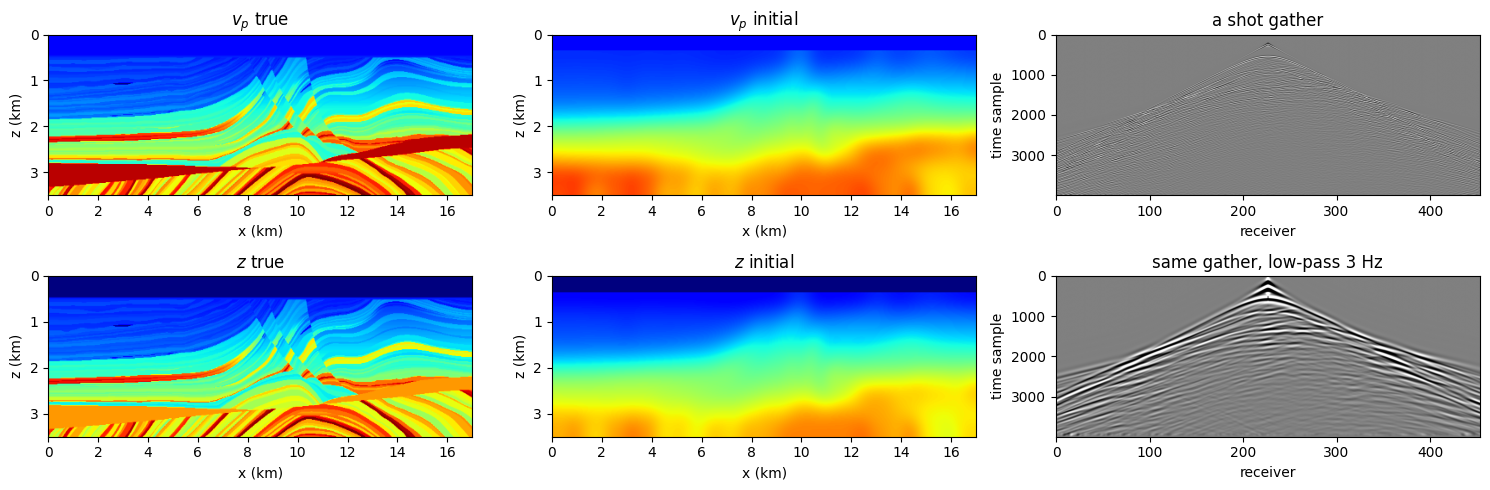

In [4]:
# true / initial models (v_p and impedance z) and one shot gather, raw and low-passed to 3 Hz
ext = [0, nx*DH/1000, nz*DH/1000, 0]
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
vk_vp = dict(cmap="jet", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())
vk_z  = dict(cmap="jet", aspect="auto", extent=ext, vmin=z_true.min(),  vmax=z_true.max())
for a, (t, m) in zip(axes[0, :2], [("$v_p$ true", vp_true), ("$v_p$ initial", vp_init)]):
    a.imshow(m, **vk_vp); a.set_title(t); a.set_xlabel("x (km)"); a.set_ylabel("z (km)")
for a, (t, m) in zip(axes[1, :2], [("$z$ true", z_true), ("$z$ initial", z_init)]):
    a.imshow(m, **vk_z); a.set_title(t); a.set_xlabel("x (km)"); a.set_ylabel("z (km)")
g = observed[len(sources)//2]                                     # (nt, nrec, 1)
gf = F.lowpass_zerophase(g[None], DT, 3.0)[0]                     # 3 Hz stage view
for a, (t, d) in zip([axes[0, 2], axes[1, 2]],
                     [("a shot gather", g), ("same gather, low-pass 3 Hz", gf)]):
    d = d[..., 0].detach().cpu().numpy(); v = np.percentile(np.abs(d), 98)
    a.imshow(d, cmap="gray", aspect="auto", vmin=-v, vmax=v)
    a.set_title(t); a.set_xlabel("receiver"); a.set_ylabel("time sample")
plt.tight_layout(); plt.show()

## Joint $(v_p, z)$ implicit FWI — hash encoding + multiscale with per-scale restart

Each scale rebuilds the network + optimizer and bakes the previous scale's model into the
init. The band-pass is a zero-phase Butterworth `filtfilt` (`torchaudio`, fp64) — matching
scipy; a frequency-domain `|H|²` multiply instead leaves a coherent t=0 wrap artefact that
destabilises the joint inversion.

In [5]:
print("Joint (v_p, z) implicit FWI - hash encoding + multiscale with per-scale restart")
def _net_factory():
    return F.MultiParamNet(shape, std=STD, mean=MEAN, hidden=HIDDEN, layers=LAYERS,
                           omega=OMEGA, hash_cfg=HASH_CFG, device=dev)
def _run():
    torch.manual_seed(F.SEED)
    print(f"network parameters: {sum(p.numel() for p in _net_factory().parameters()):,}")
    return F.run_ifwim_restart(
        solver, wavelet, sources, receivers, observed, _net_factory, [vp_init_t, z_init_t],
        epochs_per_scale=EPOCHS_PER_SCALE, lr=NN_LR, batch=BATCH, freqs=FREQS, dt=DT,
        misfit="l2sum", lr_decay=LR_DECAY, true_models=[vp_true, z_true], param_names=["vp", "z"])
h = F.run_cached(f"../figures/cache_{TAG}.npz", _run,
    signature=(SPATIAL_ORDER, ABCN, EPOCHS_PER_SCALE, tuple(STD), tuple(MEAN), OMEGA, HIDDEN, LAYERS,
               str(HASH_CFG), str(FREQS), NN_LR, LR_DECAY, BATCH, "restart_fs_l2sum_v2"))

Joint (v_p, z) implicit FWI - hash encoding + multiscale with per-scale restart
network parameters: 745,688


  scale 0 fc       3 ep   0  loss 2.449e+00  relL2 vp=0.1326 z=0.1602


  scale 0 fc       3 ep  25  loss 1.402e+00  relL2 vp=0.1346 z=0.1591


  scale 0 fc       3 ep  50  loss 6.608e-01  relL2 vp=0.1269 z=0.1425


  scale 0 fc       3 ep  75  loss 1.734e-01  relL2 vp=0.1164 z=0.1257


...

  scale 3 fc     all ep   0  loss 1.540e+04  relL2 vp=0.0839 z=0.0990


  scale 3 fc     all ep  25  loss 7.092e+03  relL2 vp=0.0828 z=0.0985


  scale 3 fc     all ep  50  loss 3.390e+03  relL2 vp=0.0816 z=0.0996


  scale 3 fc     all ep  75  loss 2.070e+03  relL2 vp=0.0807 z=0.1004


  scale 3 fc     all ep  99  loss 1.516e+03  relL2 vp=0.0802 z=0.1008


## Results: recovered velocity and impedance

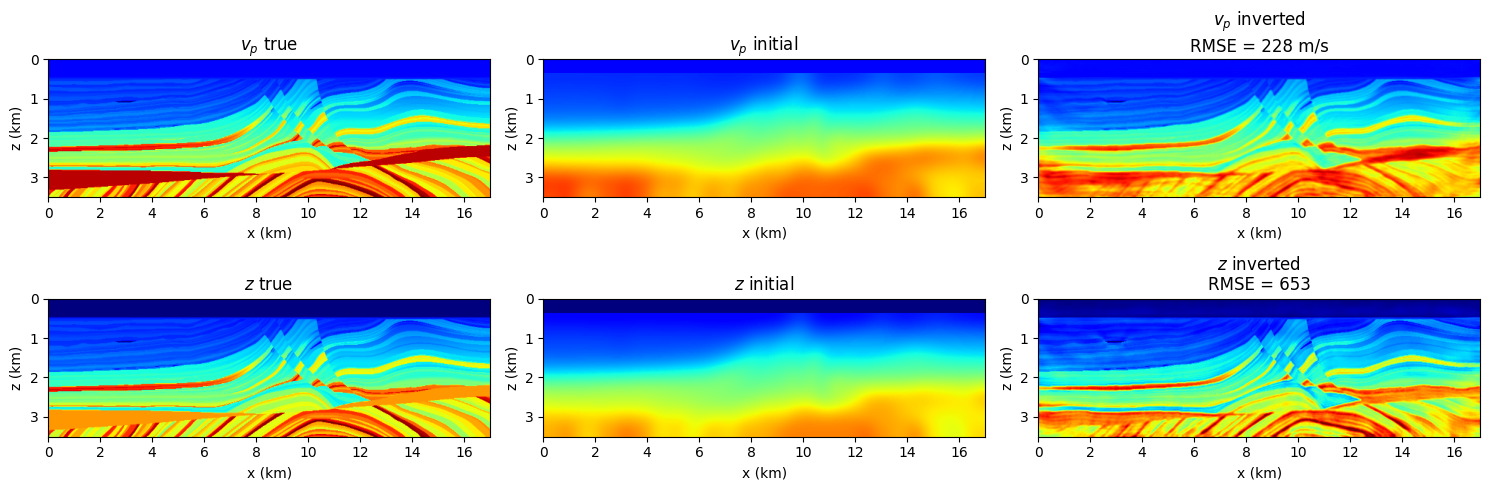

In [6]:
vp_inv, z_inv = h["vp"], h["z"]
rmse = lambda a, ref: float(np.sqrt(np.mean((a - ref) ** 2)))
ext = [0, nx*DH/1000, nz*DH/1000, 0]

fig, axes = plt.subplots(2, 3, figsize=(15, 5))
vk_vp = dict(cmap="jet", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())
vk_z  = dict(cmap="jet", aspect="auto", extent=ext, vmin=z_true.min(),  vmax=z_true.max())
row_vp = [("$v_p$ true", vp_true), ("$v_p$ initial", vp_init),
          (f"$v_p$ inverted\nRMSE = {rmse(vp_inv, vp_true):.0f} m/s", vp_inv)]
row_z  = [("$z$ true", z_true), ("$z$ initial", z_init),
          (f"$z$ inverted\nRMSE = {rmse(z_inv, z_true):.0f}", z_inv)]
for a, (t, m) in zip(axes[0], row_vp):
    a.imshow(np.nan_to_num(m, nan=float(vp_true.mean())), **vk_vp); a.set_title(t)
    a.set_xlabel("x (km)"); a.set_ylabel("z (km)")
for a, (t, m) in zip(axes[1], row_z):
    a.imshow(np.nan_to_num(m, nan=float(z_true.mean())), **vk_z); a.set_title(t)
    a.set_xlabel("x (km)"); a.set_ylabel("z (km)")
plt.tight_layout(); plt.savefig(f"../figures/{TAG}_models.png", dpi=150, bbox_inches="tight"); plt.show()

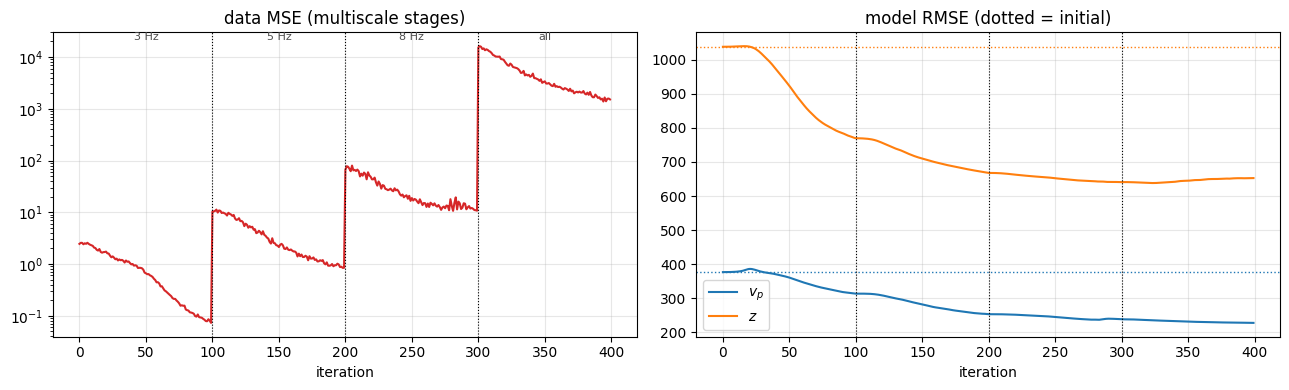

final model RMSE:  v_p = 228 m/s (initial 377)  |  z = 653 (initial 1038)


In [7]:
# convergence: data misfit (with multiscale stage boundaries) and per-parameter model RMSE
freq = np.asarray(h["freq"]); bounds = np.where(np.diff(freq) != 0)[0] + 1
labels = {3.0: "3 Hz", 5.0: "5 Hz", 8.0: "8 Hz", -1.0: "all"}
rms_vp = float(np.sqrt(np.mean(vp_true ** 2))); rms_z = float(np.sqrt(np.mean(z_true ** 2)))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].semilogy(h["loss"], color="C3")
for b in bounds: ax[0].axvline(b, color="k", ls=":", lw=0.8)
for x0, x1 in zip(np.r_[0, bounds], np.r_[bounds, len(freq)]):
    ax[0].text((x0 + x1) / 2, ax[0].get_ylim()[1], labels.get(freq[int(x0)], ""),
               ha="center", va="top", fontsize=8, color="0.3")
ax[0].set_title("data MSE (multiscale stages)"); ax[0].set_xlabel("iteration"); ax[0].grid(alpha=0.3)

ax[1].plot(np.array(h["rel_vp"]) * rms_vp, color="C0", label="$v_p$")
ax[1].plot(np.array(h["rel_z"]) * rms_z, color="C1", label="$z$")
ax[1].axhline(rmse(vp_init, vp_true), color="C0", ls=":", lw=1)
ax[1].axhline(rmse(z_init, z_true), color="C1", ls=":", lw=1)
for b in bounds: ax[1].axvline(b, color="k", ls=":", lw=0.8)
ax[1].set_title("model RMSE (dotted = initial)"); ax[1].set_xlabel("iteration")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"../figures/{TAG}_curves.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"final model RMSE:  v_p = {rmse(vp_inv, vp_true):.0f} m/s (initial {rmse(vp_init, vp_true):.0f})"
      f"  |  z = {rmse(z_inv, z_true):.0f} (initial {rmse(z_init, z_true):.0f})")